# Constraint Solving in JAXCad

`solve_constraints` finds the unique parameter values that satisfy all geometric constraints attached to a scene.
It errors immediately if the system is under- or over-constrained, so you never silently get a garbage result.

In [1]:
from jaxcad.sdf import Sphere, Translate
from jaxcad.geometry import Vector
from jaxcad.render import render_marching_cubes
from jaxcad.compiler import extract_parameters, functionalize, solve_constraints
from jaxcad.constraints import DistanceConstraint
import jax.numpy as jnp

## Scene setup — trilateration

Three anchor points at known positions and one **unknown** point `p`.
We give `p` a deliberately wrong initial guess — the solver will find the true position.

- Anchors are **fixed** (`free=False`) — they are known constants.
- `p` is **free** (`free=True`) — it is the unknown we want to solve for.

We also define `true_p = [2, 1, 0]` — the intended solution — so we can compute exact target distances.

In [2]:
anchor_a = Vector(jnp.array([0.0, 0.0, 0.0]), free=False, name='anchor_a')
anchor_b = Vector(jnp.array([4.0, 0.0, 0.0]), free=False, name='anchor_b')
anchor_c = Vector(jnp.array([2.0, 3.0, 0.0]), free=False, name='anchor_c')

true_p = jnp.array([2.0, 1.0, 0.0])   # the answer we want the solver to find

p = Vector(jnp.array([0.5, 0.5, 0.0]), free=True, name='p')  # wrong initial guess

scene = Translate(Sphere(radius=0.5), offset=p)

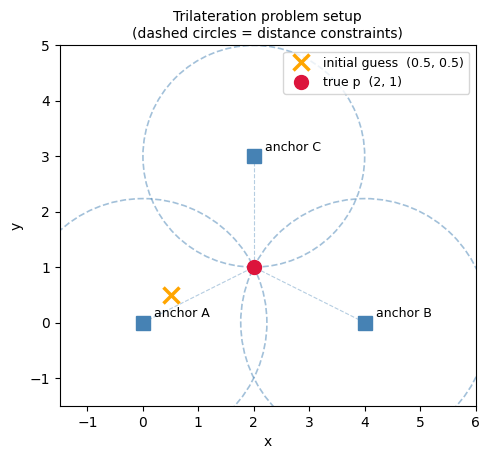

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

anchors = {
    'A': np.array([0.0, 0.0]),
    'B': np.array([4.0, 0.0]),
    'C': np.array([2.0, 3.0]),
}
true_xy  = np.array([2.0, 1.0])
guess_xy = np.array([0.5, 0.5])

fig, ax = plt.subplots(figsize=(5, 5))

# distance circles from each anchor to the true point
for name, pos in anchors.items():
    r = np.linalg.norm(true_xy - pos)
    ax.add_patch(patches.Circle(pos, r, fill=False, linestyle='--', linewidth=1.2, color='steelblue', alpha=0.5))

# anchor points
for name, pos in anchors.items():
    ax.plot(*pos, 's', color='steelblue', markersize=10, zorder=5)
    ax.annotate(f'anchor {name}', pos, textcoords='offset points', xytext=(8, 4), fontsize=9)

# initial guess
ax.plot(*guess_xy, 'x', color='orange', markersize=12, markeredgewidth=2.5, zorder=5, label='initial guess  (0.5, 0.5)')

# true solution
ax.plot(*true_xy, 'o', color='crimson', markersize=10, zorder=6, label='true p  (2, 1)')

# dashed lines: anchor → true p
for pos in anchors.values():
    ax.plot([pos[0], true_xy[0]], [pos[1], true_xy[1]], '--', color='steelblue', linewidth=0.8, alpha=0.4)

ax.set_xlim(-1.5, 6); ax.set_ylim(-1.5, 5)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Trilateration problem setup\n(dashed circles = distance constraints)', fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()


## Degrees of freedom

`p` is a 3D Vector → **3 DOF**.
Each `DistanceConstraint` enforces one scalar equation → removes **1 DOF**.
We need exactly 3 constraints to reduce to 0 remaining DOF and uniquely solve for `p`.

## Under-constrained error

Adding only one constraint leaves 2 DOF — `solve_constraints` raises a clear error.

In [3]:
DistanceConstraint(p, anchor_a, float(jnp.linalg.norm(true_p - anchor_a.value)))

try:
    solve_constraints(scene)
except ValueError as e:
    print(e)

Under-constrained: 2 DOF remaining. (3 parameter DOF, 1 constraint equations)


## Fully constrain the scene

Add the remaining two constraints — one per anchor — each with the exact distance from `true_p` to that anchor.

In [4]:
DistanceConstraint(p, anchor_b, float(jnp.linalg.norm(true_p - anchor_b.value)))
DistanceConstraint(p, anchor_c, float(jnp.linalg.norm(true_p - anchor_c.value)))

DistanceConstraint(p, anchor_c, d=2.0)

## Solve

`solve_constraints` runs Newton-Raphson to find the parameter values that satisfy all three distance constraints.

In [7]:
free_params, fixed_params = extract_parameters(scene)
solved_params = solve_constraints(scene, max_iter=10)

print("Initial p: ", p.value)
print("Solved p:  ", solved_params['translate_0.offset'].value)

Initial p:  [0.5 0.5 0. ]
Solved p:   [1.9999998 0.9999998 0.       ]


## Render at the solved position

<Axes3D: title={'center': '3D Mesh (Marching Cubes)'}, xlabel='X', ylabel='Y', zlabel='Z'>

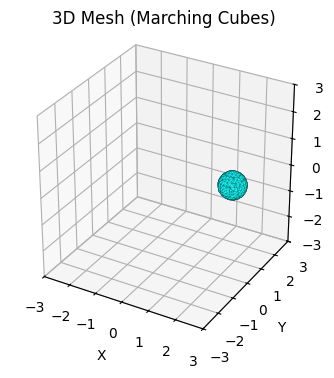

In [6]:
render_marching_cubes(
    functionalize(scene)(solved_params, fixed_params),
    figsize=(4, 4),
)

## Summary

The workflow separates two concerns:

1. **Geometry** — defined once with free parameters and constraints attached.
2. **Solved values** — computed on demand by `solve_constraints`.

The solved `free_params` dict is drop-in compatible with `functionalize`, so you can render or further optimize the scene at the constraint-satisfying position.
`solve_constraints` errors early on under-constrained systems rather than silently returning a result that doesn't satisfy the constraints.